In [43]:
import pandas as pd

orders = pd.read_csv('../data/processed/orders.csv')
people = pd.read_csv('../data/processed/people.csv')
returns = pd.read_csv('../data/processed/returns.csv')

display(orders.head())
display(people.head())
display(returns.head())

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


,person,region
0,Anna Andreadi,West
1,Chuck Magee,East
2,Kelly Williams,Central
3,Cassandra Brandow,South


,returned,order_id
0,Yes,CA-2015-100762
1,Yes,CA-2015-100762
2,Yes,CA-2015-100762
3,Yes,CA-2015-100762
4,Yes,CA-2015-100867


In [44]:
print (' Filas en returns', len(returns))
print (' Order IDs unicos', returns['order_id'].nunique())
print (' Order IDs duplicados', returns['order_id'].duplicated().sum())

 Filas en returns 800
 Order IDs unicos 296
 Order IDs duplicados 504


In [45]:
returns.duplicated().sum()

np.int64(504)

In [46]:
returns = returns.drop_duplicates().reset_index(drop= True)
returns.shape

(296, 2)

In [47]:
orders_by_order = orders[['order_id','region']].drop_duplicates()
orders_by_order.head()

,order_id,region
0,CA-2017-152156,South
2,CA-2017-138688,West
3,US-2016-108966,South
5,CA-2015-115812,West
12,CA-2018-114412,South


In [48]:
print('Filas:', len(orders_by_order))
print('Pedidos unicos:', orders_by_order['order_id'].nunique())

Filas: 5009
Pedidos unicos: 5009


In [49]:
order_returns = orders_by_order.merge(returns, on = 'order_id', how = 'left', validate = 'one_to_one')

In [50]:
display(order_returns.head(10))
print(order_returns.shape)

,order_id,region,returned
0,CA-2017-152156,South,NaN
1,CA-2017-138688,West,NaN
2,US-2016-108966,South,NaN
3,CA-2015-115812,West,NaN
4,CA-2018-114412,South,NaN
5,CA-2017-161389,West,NaN
6,US-2016-118983,Central,NaN
7,CA-2015-105893,Central,NaN
8,CA-2015-167164,West,NaN
9,CA-2015-143336,West,Yes


(5009, 3)


In [51]:
order_returns['was_returned'] = order_returns['returned'].notna()
display(order_returns.head())

,order_id,region,returned,was_returned
0,CA-2017-152156,South,NaN,False
1,CA-2017-138688,West,NaN,False
2,US-2016-108966,South,NaN,False
3,CA-2015-115812,West,NaN,False
4,CA-2018-114412,South,NaN,False


In [52]:
order_returns.groupby('region')['was_returned'].mean()

region
Central    0.033191
East       0.031406
South      0.029197
West       0.117318
Name: was_returned, dtype: float64

In [53]:
return_summary = order_returns.groupby('region')['was_returned'].agg(['count','sum','mean'])
print(return_summary)

         count  sum      mean
region                       
Central   1175   39  0.033191
East      1401   44  0.031406
South      822   24  0.029197
West      1611  189  0.117318


In [54]:
return_summary.columns = ['total_orders', 'returned_orders', 'return_rate']
return_summary['return_rate'] = return_summary['return_rate'] * 100
print(return_summary)

         total_orders  returned_orders  return_rate
region                                             
Central          1175               39     3.319149
East             1401               44     3.140614
South             822               24     2.919708
West             1611              189    11.731844


In [55]:
return_summary['return_rate'] = return_summary['return_rate'].round(2)
return_summary = return_summary.sort_values(by = 'return_rate', ascending= False)
print(return_summary)

         total_orders  returned_orders  return_rate
region                                             
West             1611              189        11.73
Central          1175               39         3.32
East             1401               44         3.14
South             822               24         2.92


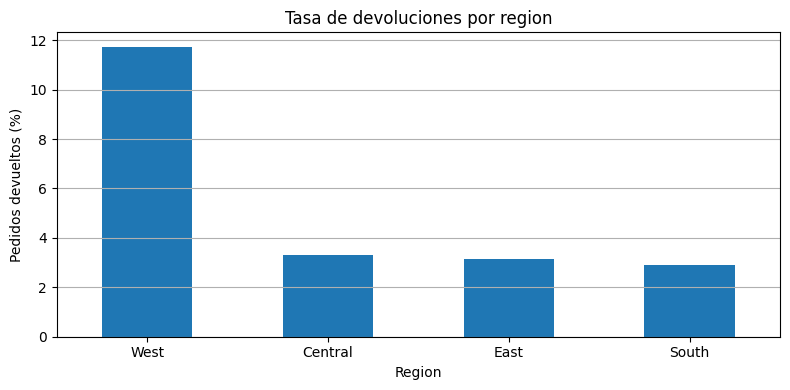

In [56]:
import matplotlib.pyplot as plt

return_summary['return_rate'].plot(kind='bar', figsize=(8,4), title ='Tasa de devoluciones por region')

plt.xlabel('Region')
plt.ylabel('Pedidos devueltos (%)')
plt.xticks(rotation = 0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

¿Qué observamos en la gráfica?
Es evidente que la tasa de devoluciones en West es aproximadamente cuatro veces mayor que en las demás regiones. Esta diferencia sugiere que puede existir algún factor particular en esta región que está aumentando las devoluciones y que merece ser investigado.

¿Qué investigaríamos después?
Analizaría las categorías y productos vendidos en West para identificar si las devoluciones se concentran en algún grupo específico. También podría revisarse posteriormente si existen relaciones con descuentos, ventas o rentabilidad.

In [57]:
order_category = orders[['order_id','region','category']].drop_duplicates()
order_category.head(10)

,order_id,region,category
0,CA-2017-152156,South,Furniture
2,CA-2017-138688,West,Office Supplies
3,US-2016-108966,South,Furniture
4,US-2016-108966,South,Office Supplies
5,CA-2015-115812,West,Furniture
6,CA-2015-115812,West,Office Supplies
7,CA-2015-115812,West,Technology
12,CA-2018-114412,South,Office Supplies
13,CA-2017-161389,West,Office Supplies
14,US-2016-118983,Central,Office Supplies


In [58]:
order_category_returns = order_category.merge(returns,on= 'order_id',how = 'left',validate='many_to_one')
order_category_returns.head(10)

,order_id,region,category,returned
0,CA-2017-152156,South,Furniture,NaN
1,CA-2017-138688,West,Office Supplies,NaN
2,US-2016-108966,South,Furniture,NaN
3,US-2016-108966,South,Office Supplies,NaN
4,CA-2015-115812,West,Furniture,NaN
5,CA-2015-115812,West,Office Supplies,NaN
6,CA-2015-115812,West,Technology,NaN
7,CA-2018-114412,South,Office Supplies,NaN
8,CA-2017-161389,West,Office Supplies,NaN
9,US-2016-118983,Central,Office Supplies,NaN


In [59]:
order_category_returns['was_returned'] = order_category_returns['returned'].notna()
order_category_returns.head(10)

,order_id,region,category,returned,was_returned
0,CA-2017-152156,South,Furniture,NaN,False
1,CA-2017-138688,West,Office Supplies,NaN,False
2,US-2016-108966,South,Furniture,NaN,False
3,US-2016-108966,South,Office Supplies,NaN,False
4,CA-2015-115812,West,Furniture,NaN,False
5,CA-2015-115812,West,Office Supplies,NaN,False
6,CA-2015-115812,West,Technology,NaN,False
7,CA-2018-114412,South,Office Supplies,NaN,False
8,CA-2017-161389,West,Office Supplies,NaN,False
9,US-2016-118983,Central,Office Supplies,NaN,False


In [62]:
west_category_return= order_category_returns[order_category_returns['region'] == 'West']
west_category_return.head()

,order_id,region,category,returned,was_returned
1,CA-2017-138688,West,Office Supplies,NaN,False
4,CA-2015-115812,West,Furniture,NaN,False
5,CA-2015-115812,West,Office Supplies,NaN,False
6,CA-2015-115812,West,Technology,NaN,False
8,CA-2017-161389,West,Office Supplies,NaN,False


In [67]:
west_category_return.groupby('category')['was_returned'].mean()*100

category
Furniture          14.789916
Office Supplies    12.745937
Technology         13.877551
Name: was_returned, dtype: float64

In [71]:
category_return_rates = order_category_returns.groupby(['region','category'])['was_returned'].mean()*100
print(category_return_rates)

region   category       
Central  Furniture           3.225806
         Office Supplies     3.636364
         Technology          3.651685
East     Furniture           4.508197
         Office Supplies     3.165736
         Technology          6.546275
South    Furniture           4.676259
         Office Supplies     3.069467
         Technology          5.098039
West     Furniture          14.789916
         Office Supplies    12.745937
         Technology         13.877551
Name: was_returned, dtype: float64


Que patron observas al comparar las categorias entre regiones? Particularmente no se nota claramente una categoria que este generando mas devoliciones, parece ser algo muy particular solo en west
Que i nvestigarias despues al ver este resultado? Al no tener relacion las categorias tenemos opciones extra para investigar como por ejemplo podria ser fechas, tipo de envio ship_mode, city, customer name entre otras

In [73]:
category_return_table = category_return_rates.unstack()
category_return_table

category,Furniture,Office Supplies,Technology
region,,,
Central,3.225806,3.636364,3.651685
East,4.508197,3.165736,6.546275
South,4.676259,3.069467,5.098039
West,14.789916,12.745937,13.877551


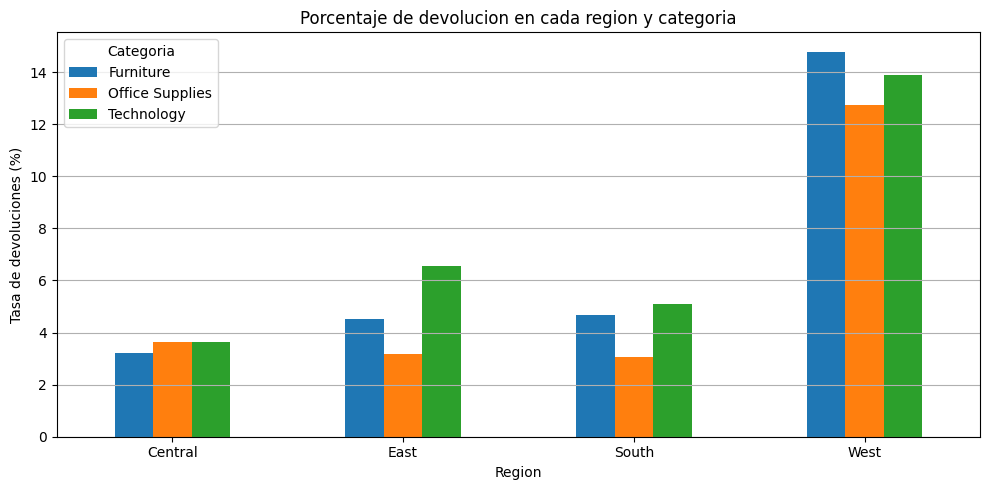

In [77]:
category_return_table.plot(kind = 'bar', figsize = (10,5))

plt.title('Porcentaje de devolucion en cada region y categoria')
plt.xlabel('Region')
plt.ylabel('Tasa de devoluciones (%)')
plt.xticks(rotation = 0)
plt.grid(axis= 'y')
plt.legend(title = 'Categoria')
plt.tight_layout()
plt.show()

En la gráfica podemos comparar la tasa de devoluciones por región y categoría. Se observa que West presenta tasas considerablemente más altas en Furniture, Office Supplies y Technology, aproximadamente entre tres y cuatro veces superiores a las de las demás regiones. Esto sugiere que el patrón no parece estar concentrado en una sola categoría y que conviene investigar otras variables propias de West.